In [1]:
%%capture
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import astropy.units as u
from pathlib import Path
from astropy.coordinates import SkyCoord
from astromodels.functions.function import Function1D, FunctionMeta
from cosipy import SpacecraftFile, SourceInjector
from histpy import Histogram
from threeML import Powerlaw, Band
from cosipy.threeml.custom_functions import SpecFromDat
from cosipy.util import fetch_wasabi_file
import shutil
import os
import pandas as pd

%matplotlib inline

In [2]:
data_dir = Path("/Users/parshad/Software/cosipyFiles")  # Current directory by default. Modify if you want a different path

In [17]:
%%capture
zipped_response_path = data_dir/"psr_gal_continuum_DC2.h5.zip"
response_path = data_dir/"psr_gal_DC2.h5"

# # download response file ~839.62 MB
# if not response_path.exists():
    
    # fetch_wasabi_file("COSI-SMEX/DC2/Responses/PointSourceReponse/psr_gal_continuum_DC2.h5.zip", zipped_response_path)

    # # unzip the response file
    # shutil.unpack_archive(zipped_response_path)

    # # delete the zipped response to save space
    # os.remove(zipped_response_path)

In [18]:
%%capture
orientation_path = data_dir/"20280301_3_month_with_orbital_info.ori"

# # download orientation file ~684.38 MB
# if not orientation_path.exists():
#     fetch_wasabi_file("COSI-SMEX/DC2/Data/Orientation/20280301_3_month.ori", orientation_path)

In [19]:
# spectrum = SpecFromDat(K=1/18, dat="crab_spec.dat")

# spectrum = SpecFromDat(K=1, dat="/Users/parshad/Software/AGN_Coronae/NGC_4151_ec200_COSI.dat")
# spectrum = SpecFromDat(K=1, dat="/Users/parshad/Software/AGN_Coronae/NGC_4151_ec1000_COSI.dat")
spectrum = SpecFromDat(K=0.00174, dat="/Users/parshad/Software/AGN_Coronae/NGC_4151_ec200_COSI.dat")
# spectrum = SpecFromDat(K=0.00372, dat="/Users/parshad/Software/AGN_Coronae/NGC_4151_ec1000_COSI.dat")

In [20]:
# Read the 3-month orientation
# It is the pointing of the spacecraft during the the mock simlulation
ori = SpacecraftFile.parse_from_file(orientation_path)

In [21]:
# Define an injector by the response
injector = SourceInjector(response_path=response_path, response_frame="galactic")

In [ ]:
# Define the coordinate of the point source
# Need to change this eventually
source_coord = SkyCoord(s frame="galactic", unit="deg")

CPU times: user 978 ms, sys: 303 ms, total: 1.28 s
Wall time: 1.16 s


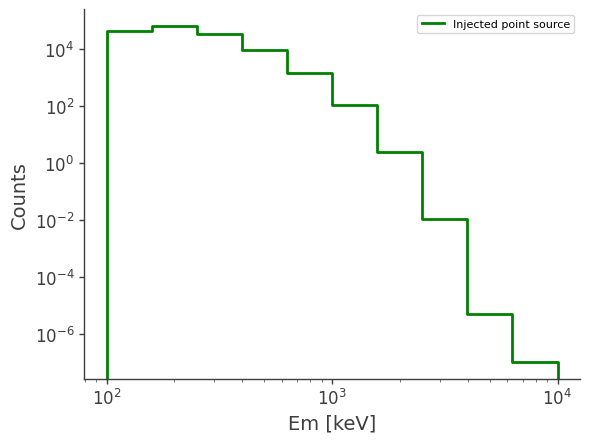

In [23]:
%%time

file_path = "/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec200_COSI_sourceInj_correctFlux.hdf5"



# Check if the file exists and remove it if it does
if os.path.exists(file_path):
    os.remove(file_path)

# Get the data of the injected source
injector.inject_point_source(spectrum=spectrum, coordinate=source_coord, orientation=ori, source_name="NGC4151ec200",
                             make_spectrum_plot=True, data_save_path=file_path, project_axes=None)